In [ ]:
# %pip install --upgrade pandas numpy scipy scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option('display.max_columns', None)

# for reproducibility
RANDOM = 44

### Feature Engineering and Data Cleaning

Based on results from EDA

The following steps will be taken to prep data for machine learning:

*Remove cols:*
- price - keeping price_usd as price variable
- ships_worldwide - highly correlated with seller_listing_count

Likely will not use any graded cols in the final result but will keep in case I do.

*Features created:*
- price_usd_log.- logarithm of price_usd for more normal dist
- title_length - character count of title of card
- 



### Notes:

For this analysis I have decided to drop grading related columns, as these are generally a different product than raw cards are. These are more collectible items and have different utility when graded. Since only a small fraction of the entries in this dataset are graded, I will be dropping them to their own dataset, but could add them back in if necessary.

In [2]:
df = pd.read_csv('./pokemon_cards_ultimate_2026.csv')

# keep as separate df just in case
df_graded = df[df['is_graded'] == 1]

# keep original dataframe with ungraded cards
df = df[df['is_graded'] != 1]  

# drop graded related cols from the ungraded dataset
grading_cols = ['is_graded', 'grading_company', 'numeric_grade']
df = df.drop(columns=grading_cols)

# **NOTES** All of these records in the dataset were captured in a very small timeframe, therefore the columns relating to sale month, year, etc will be dropped.
selling_cols = ['days_since_sold', 'sale_month', 'sale_year']
df = df.drop(columns=selling_cols)

df.info()

<class 'pandas.DataFrame'>
Index: 503 entries, 0 to 541
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 503 non-null    str    
 1   pokemon_name          503 non-null    str    
 2   set_name              503 non-null    str    
 3   card_number           395 non-null    str    
 4   rarity_class          503 non-null    str    
 5   language              503 non-null    str    
 6   category              503 non-null    str    
 7   condition_std         503 non-null    str    
 8   is_holo               503 non-null    int64  
 9   is_full_art           503 non-null    int64  
 10  is_v_card             503 non-null    int64  
 11  is_ex_card            503 non-null    int64  
 12  is_gx_card            503 non-null    int64  
 13  is_promo              503 non-null    int64  
 14  is_shadowless         503 non-null    int64  
 15  is_1st_edition        503 non-null    i

In [3]:
# check out missing and duplicate entries
missing = df.isna().sum()
missing = missing.sort_values(ascending=False)
print(missing)

dups = df.duplicated()
display(df[dups])

card_number             108
title                     0
is_shadowless             0
ships_worldwide           0
seller_listing_count      0
seller_country            0
price_tier_usd            0
price_usd                 0
currency                  0
price                     0
is_gold                   0
is_rainbow                0
is_1st_edition            0
is_promo                  0
pokemon_name              0
is_gx_card                0
is_ex_card                0
is_v_card                 0
is_full_art               0
is_holo                   0
condition_std             0
category                  0
language                  0
rarity_class              0
set_name                  0
image_count               0
dtype: int64


,title,pokemon_name,set_name,card_number,rarity_class,language,category,condition_std,is_holo,is_full_art,is_v_card,is_ex_card,is_gx_card,is_promo,is_shadowless,is_1st_edition,is_rainbow,is_gold,price,currency,price_usd,price_tier_usd,seller_country,seller_listing_count,ships_worldwide,image_count
29,Emboar Holo 008/037 HS 2010 Vintage Rare Ninte...,Unknown,Unknown,008/037,Rare,Japanese,Single Cards,Excellent,1,0,0,0,0,0,0,0,0,0,1.0,EUR,1.17,Budget,Germany,114,1,2


In [4]:
# drop single duplicated row -> overwhlemingly likely to be an erroneous record
df = df.drop_duplicates()

For card number, I am going to separate into 2 cols, the card number (first number before the slash), and the second number is the number of cards in the set. I will potentially also create a new column that is the position in the set by a percentage?

In [5]:
# split between the /
df[['card_number', 'set_card_amount']] = df['card_number'].astype(str).str.split('/', n=1, expand=True)

# convert to ints
df['card_number'] = pd.to_numeric(df['card_number'], errors='coerce').astype('Int64') 
df['set_card_amount'] = pd.to_numeric(df['set_card_amount'], errors='coerce').astype('Int64') 

In [6]:
df[['card_number', 'set_card_amount']].describe()

,card_number,set_card_amount
count,394.0,394.0
mean,81.091371,115.568528
std,72.45788,51.111131
min,1.0,12.0
25%,23.0,80.0
50%,67.0,102.0
75%,108.0,146.25
max,401.0,236.0


For this analysis I am going to impute the mean to all missing cols in the card number and set card amount to the missing values. Since there are outliers, this should account for outliers too.

In [7]:
print(df['card_number'].median())
print(df['set_card_amount'].median())

67.0
102.0


In [8]:
df['card_number'] = df['card_number'].fillna(df['card_number'].median())
df['set_card_amount'] = df['set_card_amount'].fillna(df['set_card_amount'].median())

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 502 entries, 0 to 541
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 502 non-null    str    
 1   pokemon_name          502 non-null    str    
 2   set_name              502 non-null    str    
 3   card_number           502 non-null    Int64  
 4   rarity_class          502 non-null    str    
 5   language              502 non-null    str    
 6   category              502 non-null    str    
 7   condition_std         502 non-null    str    
 8   is_holo               502 non-null    int64  
 9   is_full_art           502 non-null    int64  
 10  is_v_card             502 non-null    int64  
 11  is_ex_card            502 non-null    int64  
 12  is_gx_card            502 non-null    int64  
 13  is_promo              502 non-null    int64  
 14  is_shadowless         502 non-null    int64  
 15  is_1st_edition        502 non-null    i

In [10]:
# copy over for encoding variables
df_cleaned = df.copy()

# title will not be used in the model as it is a string variable, create a title length variable as a surrogate
df_cleaned['title_length'] = df_cleaned['title'].str.len()
df_cleaned = df_cleaned.drop(columns='title')

# pokemon name and set name are both going to be nominal categorical variables
# using pandas get_dummies to encode for machine learning methods
nominal_categorical = ["pokemon_name", 'set_name', 'language']
# make these all lowercase only first
for col in nominal_categorical:
    df_cleaned[col] = df_cleaned[col].str.lower()
df_cleaned = pd.get_dummies(df_cleaned, columns=nominal_categorical, dtype=int)

# ordinal categorical values:
# rarity class - this has order -> these are in order according to pokemon card sources
ordered_rarities = [
    "Unknown",
    "Common",
    "Uncommon",
    "Rare",
    "Rare Holo",
    "RR",
    "AR",
    "IR",
    "SR",
    "UR",
    "SAR",
    "SIR",
    "HR",
]
df_cleaned["rarity_class"] = pd.Categorical(
    df_cleaned["rarity_class"], categories=ordered_rarities, ordered=True
)
df_cleaned["rarity_class"] = df_cleaned["rarity_class"].cat.codes

# condition states according to research done on the topic
ordered_conditons = [
    "Very Good",
    "Lightly Played",
    "Excellent",
    "Near Mint",
]
df_cleaned['condition_std'] = pd.Categorical(
    df_cleaned['condition_std'], categories=ordered_conditons, ordered=True
)
df_cleaned['condition_std'] = df_cleaned['condition_std'].cat.codes

In [11]:
# the following cols should not impact the inherent value of the card, but rather could have other costs associated such as shipping costs, etc so will be removed for modeling
# seller_country, seller_listing_count, ships_worldwide, image_count
# uninformative cols to drop
# cateogory - same meaning for all
# currency - using usd as standard
# price_tier_usd - likely highly correlated with response variable
cols_to_drop = [
    'seller_country',
    'seller_listing_count',
    'ships_worldwide',
    'image_count',
    'category',
    'currency',
    'price_tier_usd'
]

df_cleaned = df_cleaned.drop(columns=cols_to_drop)
df_cleaned.head()

,card_number,rarity_class,condition_std,is_holo,is_full_art,is_v_card,is_ex_card,is_gx_card,is_promo,is_shadowless,is_1st_edition,is_rainbow,is_gold,price,price_usd,set_card_amount,title_length,pokemon_name_absol,pokemon_name_alakazam,pokemon_name_arcanine,pokemon_name_arceus,pokemon_name_articuno,pokemon_name_bellibolt,pokemon_name_blastoise,pokemon_name_bulbasaur,pokemon_name_butterfree,pokemon_name_calyrex,pokemon_name_ceruledge,pokemon_name_charizard,pokemon_name_charmander,pokemon_name_cresselia,pokemon_name_darkrai,pokemon_name_deoxys,pokemon_name_dialga,pokemon_name_dragapult,pokemon_name_dragonite,pokemon_name_eevee,pokemon_name_espeon,pokemon_name_flareon,pokemon_name_froslass,pokemon_name_garchomp,pokemon_name_gardevoir,pokemon_name_gengar,pokemon_name_giratina,pokemon_name_glaceon,pokemon_name_golisopod,pokemon_name_greninja,pokemon_name_groudon,pokemon_name_gyarados,pokemon_name_infernape,pokemon_name_ivysaur,pokemon_name_jolteon,pokemon_name_kyurem,pokemon_name_lapras,pokemon_name_latias,pokemon_name_leafeon,pokemon_name_lucario,pokemon_name_lugia,pokemon_name_machamp,pokemon_name_manaphy,pokemon_name_meowth,pokemon_name_mew,pokemon_name_mewtwo,pokemon_name_moltres,pokemon_name_palafin,pokemon_name_palkia,pokemon_name_pidgeot,pokemon_name_pikachu,pokemon_name_piplup,pokemon_name_psyduck,pokemon_name_raichu,pokemon_name_rattata,pokemon_name_rayquaza,pokemon_name_rotom,pokemon_name_snorlax,pokemon_name_spiritomb,pokemon_name_squirtle,pokemon_name_staraptor,pokemon_name_talonflame,pokemon_name_tyranitar,pokemon_name_umbreon,pokemon_name_unknown,pokemon_name_vaporeon,pokemon_name_venusaur,pokemon_name_vulpix,pokemon_name_weavile,pokemon_name_xerneas,pokemon_name_yveltal,pokemon_name_zacian,pokemon_name_zamazenta,pokemon_name_zapdos,pokemon_name_zoroark,set_name_astral radiance,set_name_base set,set_name_burning shadows,set_name_bw,set_name_bw1,set_name_bw7,set_name_bw8,set_name_bw88,set_name_bw89,set_name_bw9,set_name_bw90,set_name_bw92,set_name_crown zenith,set_name_darkness ablaze,set_name_dp,set_name_dp2,set_name_dp3,set_name_dp5,set_name_evolving skies,set_name_fossil,set_name_hidden fates,set_name_inferno x,set_name_jungle,set_name_mega brave,set_name_paldea evolved,set_name_paldean fates,set_name_paradox rift,set_name_s10a,set_name_s12,set_name_s12a,set_name_s4a,set_name_s6a,set_name_s8b,set_name_s9,set_name_s9a,set_name_silver tempest,set_name_sm10,set_name_sm11b,set_name_sm12a,set_name_sm171,set_name_sm3n,set_name_sm7b,set_name_sm8b,set_name_sm9,set_name_surging sparks,set_name_sv11b,set_name_sv1a,set_name_sv1s,set_name_sv2,set_name_sv2a,set_name_sv2p,set_name_sv38,set_name_sv4m,set_name_sv6,set_name_sv6a,set_name_sv7a,set_name_sv8,set_name_sv8a,set_name_sv9,set_name_sv9a,set_name_swsh,set_name_swsh132,set_name_team rocket,set_name_temporal forces,set_name_twilight masquerade,set_name_unknown,set_name_vstar universe,set_name_xy,set_name_xy11,set_name_xy6,set_name_xy8,set_name_xy9,set_name_xy95,set_name_xyb,language_chinese,language_english,language_german,language_italian,language_japanese,language_korean
0,203,10,3,0,0,0,1,0,0,0,0,0,0,15.43,20.99,187,70,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,225,10,3,1,0,1,0,0,0,0,0,0,0,11.15,15.17,172,67,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,85,6,3,0,0,0,0,0,0,0,0,0,0,2.91,3.96,80,70,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

Maybe drop title length??????? as this is not an inherent property to the card itself???

In [21]:
# feature engineering
# log price
df_ml = df_cleaned.copy()

df_ml['price_log_usd'] = np.log10(df_ml['price_usd'] + 1)
df_ml = df_ml.drop(columns=['price', 'price_usd'])

# create a ratio col for card num / set card number
df_ml['set_position_ratio'] = df_ml['card_number'] / df_ml['set_card_amount']
df_ml = df_ml.drop(columns=['card_number', 'set_card_amount'])
 
df_ml

,rarity_class,condition_std,is_holo,is_full_art,is_v_card,is_ex_card,is_gx_card,is_promo,is_shadowless,is_1st_edition,is_rainbow,is_gold,title_length,pokemon_name_absol,pokemon_name_alakazam,pokemon_name_arcanine,pokemon_name_arceus,pokemon_name_articuno,pokemon_name_bellibolt,pokemon_name_blastoise,pokemon_name_bulbasaur,pokemon_name_butterfree,pokemon_name_calyrex,pokemon_name_ceruledge,pokemon_name_charizard,pokemon_name_charmander,pokemon_name_cresselia,pokemon_name_darkrai,pokemon_name_deoxys,pokemon_name_dialga,pokemon_name_dragapult,pokemon_name_dragonite,pokemon_name_eevee,pokemon_name_espeon,pokemon_name_flareon,pokemon_name_froslass,pokemon_name_garchomp,pokemon_name_gardevoir,pokemon_name_gengar,pokemon_name_giratina,pokemon_name_glaceon,pokemon_name_golisopod,pokemon_name_greninja,pokemon_name_groudon,pokemon_name_gyarados,pokemon_name_infernape,pokemon_name_ivysaur,pokemon_name_jolteon,pokemon_name_kyurem,pokemon_name_lapras,pokemon_name_latias,pokemon_name_leafeon,pokemon_name_lucario,pokemon_name_lugia,pokemon_name_machamp,pokemon_name_manaphy,pokemon_name_meowth,pokemon_name_mew,pokemon_name_mewtwo,pokemon_name_moltres,pokemon_name_palafin,pokemon_name_palkia,pokemon_name_pidgeot,pokemon_name_pikachu,pokemon_name_piplup,pokemon_name_psyduck,pokemon_name_raichu,pokemon_name_rattata,pokemon_name_rayquaza,pokemon_name_rotom,pokemon_name_snorlax,pokemon_name_spiritomb,pokemon_name_squirtle,pokemon_name_staraptor,pokemon_name_talonflame,pokemon_name_tyranitar,pokemon_name_umbreon,pokemon_name_unknown,pokemon_name_vaporeon,pokemon_name_venusaur,pokemon_name_vulpix,pokemon_name_weavile,pokemon_name_xerneas,pokemon_name_yveltal,pokemon_name_zacian,pokemon_name_zamazenta,pokemon_name_zapdos,pokemon_name_zoroark,set_name_astral radiance,set_name_base set,set_name_burning shadows,set_name_bw,set_name_bw1,set_name_bw7,set_name_bw8,set_name_bw88,set_name_bw89,set_name_bw9,set_name_bw90,set_name_bw92,set_name_crown zenith,set_name_darkness ablaze,set_name_dp,set_name_dp2,set_name_dp3,set_name_dp5,set_name_evolving skies,set_name_fossil,set_name_hidden fates,set_name_inferno x,set_name_jungle,set_name_mega brave,set_name_paldea evolved,set_name_paldean fates,set_name_paradox rift,set_name_s10a,set_name_s12,set_name_s12a,set_name_s4a,set_name_s6a,set_name_s8b,set_name_s9,set_name_s9a,set_name_silver tempest,set_name_sm10,set_name_sm11b,set_name_sm12a,set_name_sm171,set_name_sm3n,set_name_sm7b,set_name_sm8b,set_name_sm9,set_name_surging sparks,set_name_sv11b,set_name_sv1a,set_name_sv1s,set_name_sv2,set_name_sv2a,set_name_sv2p,set_name_sv38,set_name_sv4m,set_name_sv6,set_name_sv6a,set_name_sv7a,set_name_sv8,set_name_sv8a,set_name_sv9,set_name_sv9a,set_name_swsh,set_name_swsh132,set_name_team rocket,set_name_temporal forces,set_name_twilight masquerade,set_name_unknown,set_name_vstar universe,set_name_xy,set_name_xy11,set_name_xy6,set_name_xy8,set_name_xy9,set_name_xy95,set_name_xyb,language_chinese,language_english,language_german,language_italian,language_japanese,language_korean,price_log_usd,set_position_ratio
0,10,3,0,0,0,1,0,0,0,0,0,0,70,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1.342225,1.085561
1,10,3,1,0,1,0,0,0,0,0,0,0,67,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1.208710,1.30814
2,6,3,0,0,0,0,0,0,0,0,0,0,70,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [13]:
# split features and response
X = df_ml.drop(columns='price_log_usd').copy()
y = df_ml['price_log_usd'].copy()

Dataset is now prepped for machine learning methods

**Notes:**

For determining the encoding of the condition_std col I used this source: https://pokescope.app/condition-guide/ to determine the row. 

Using this function from the scikitlearn documentation: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html

Am condsidering separating graded cards from the rest of the dataset tbh, as the market for these is generally completely different...


---

## Model 1: Linear Regression Model

TODO: Need to ensure that the data is fully ready to be used on this, separate columns that will and will not be used for stuff, like date cols can be dropped. Additioanlly, keep the is_graded flag away from the other ones as it is quite niche and will obviously positively correlate to a high extent.

In [14]:
# test train split 80/20

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM
)
print(f'Training set size: {X_train.shape[0]}')
print(f'Test set size: {X_test.shape[0]}')

Training set size: 401
Test set size: 101


In [15]:
pokemon_lm = LinearRegression()
pokemon_lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](170,)","[ 0. , 0.02, 0.09,..., 1.1 ,-0.32, 0.4 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](170,)","['card_number','rarity_class','condition_std',...,'language_italian', 'language_japanese','language_korean']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.873
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,170
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(144)


In [16]:
y_pred = pokemon_lm.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print(f'Test RMSE: {test_rmse:.2f}')
print(f'Test R²:   {test_r2:.4f}')

Test RMSE: 0.48
Test R²:   0.2306


In [17]:
coef_df = pd.DataFrame({
    'Feature': X.columns if hasattr(X, 'columns') else range(X.shape[1]),
    'Coefficient': pokemon_lm.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(f"Intercept (Base Value): {pokemon_lm.intercept_:.2f}\n")
print(coef_df.to_string(index=False))

Intercept (Base Value): 0.87

                     Feature   Coefficient
              set_name_sm171 -1.216076e+00
            pokemon_name_mew  1.106503e+00
            language_italian  1.102556e+00
            language_chinese -1.003661e+00
        pokemon_name_groudon  9.774753e-01
     pokemon_name_charmander -8.580122e-01
      pokemon_name_blastoise  8.343075e-01
     set_name_vstar universe  7.885093e-01
set_name_twilight masquerade  7.600004e-01
                set_name_s6a -7.543297e-01
               set_name_sv2a  7.424778e-01
      pokemon_name_charizard  7.420256e-01
      pokemon_name_bellibolt -6.990009e-01
               set_name_bw89  6.470599e-01
         pokemon_name_dialga -6.447863e-01
     set_name_evolving skies -6.435890e-01
               set_name_sm3n -6.406735e-01
          pokemon_name_lugia  6.351699e-01
      pokemon_name_golisopod -6.295037e-01
        pokemon_name_pikachu  6.272958e-01
       pokemon_name_gyarados  6.173733e-01
         pokemon_name_me

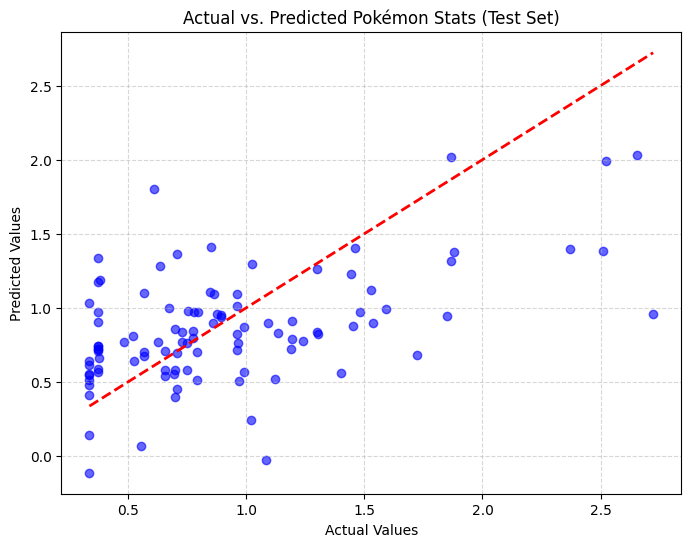

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='b')

# Red dashed diagonal line representing a perfect 1:1 prediction
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2,
)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Pokémon Stats (Test Set)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [19]:
y_train_pred = pokemon_lm.predict(X_train)
y_test_pred = pokemon_lm.predict(X_test)

# calculate scores
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train R²: {train_r2:.4f}")
print(f"Test R²:  {test_r2:.4f}")

Train R²: 0.5859
Test R²:  0.2306
